In [1]:
!git clone https://github.com/Afonso-Leal/unsupervised_water_quality_prediction.git

Cloning into 'unsupervised_water_quality_prediction'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 38 (delta 14), reused 24 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 454.03 KiB | 16.82 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [2]:
cd unsupervised_water_quality_prediction/

/content/unsupervised_water_quality_prediction


In [3]:
pip install tensorboard

In [4]:

from model_dense import Encoder as enc_dense
from model_dense import Decoder as dec_dense
from model_dense import EncoderDecoder as auto_dense
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from preprossesing import WaterQualityDataOrganization
from trainer import Trainer
from utils import *
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd

In [5]:
wq_org = WaterQualityDataOrganization(import_data())
wq_org.preprocessing()

In [6]:
X_train_dataset = WaterQualityDataset(wq_org.x_train.to_numpy(),wq_org.x_train.to_numpy())
X_val_dataset = WaterQualityDataset(wq_org.x_val.to_numpy(),wq_org.x_val.to_numpy())
X_test_dataset = WaterQualityDataset(wq_org.x_test.to_numpy(),wq_org.x_test.to_numpy())

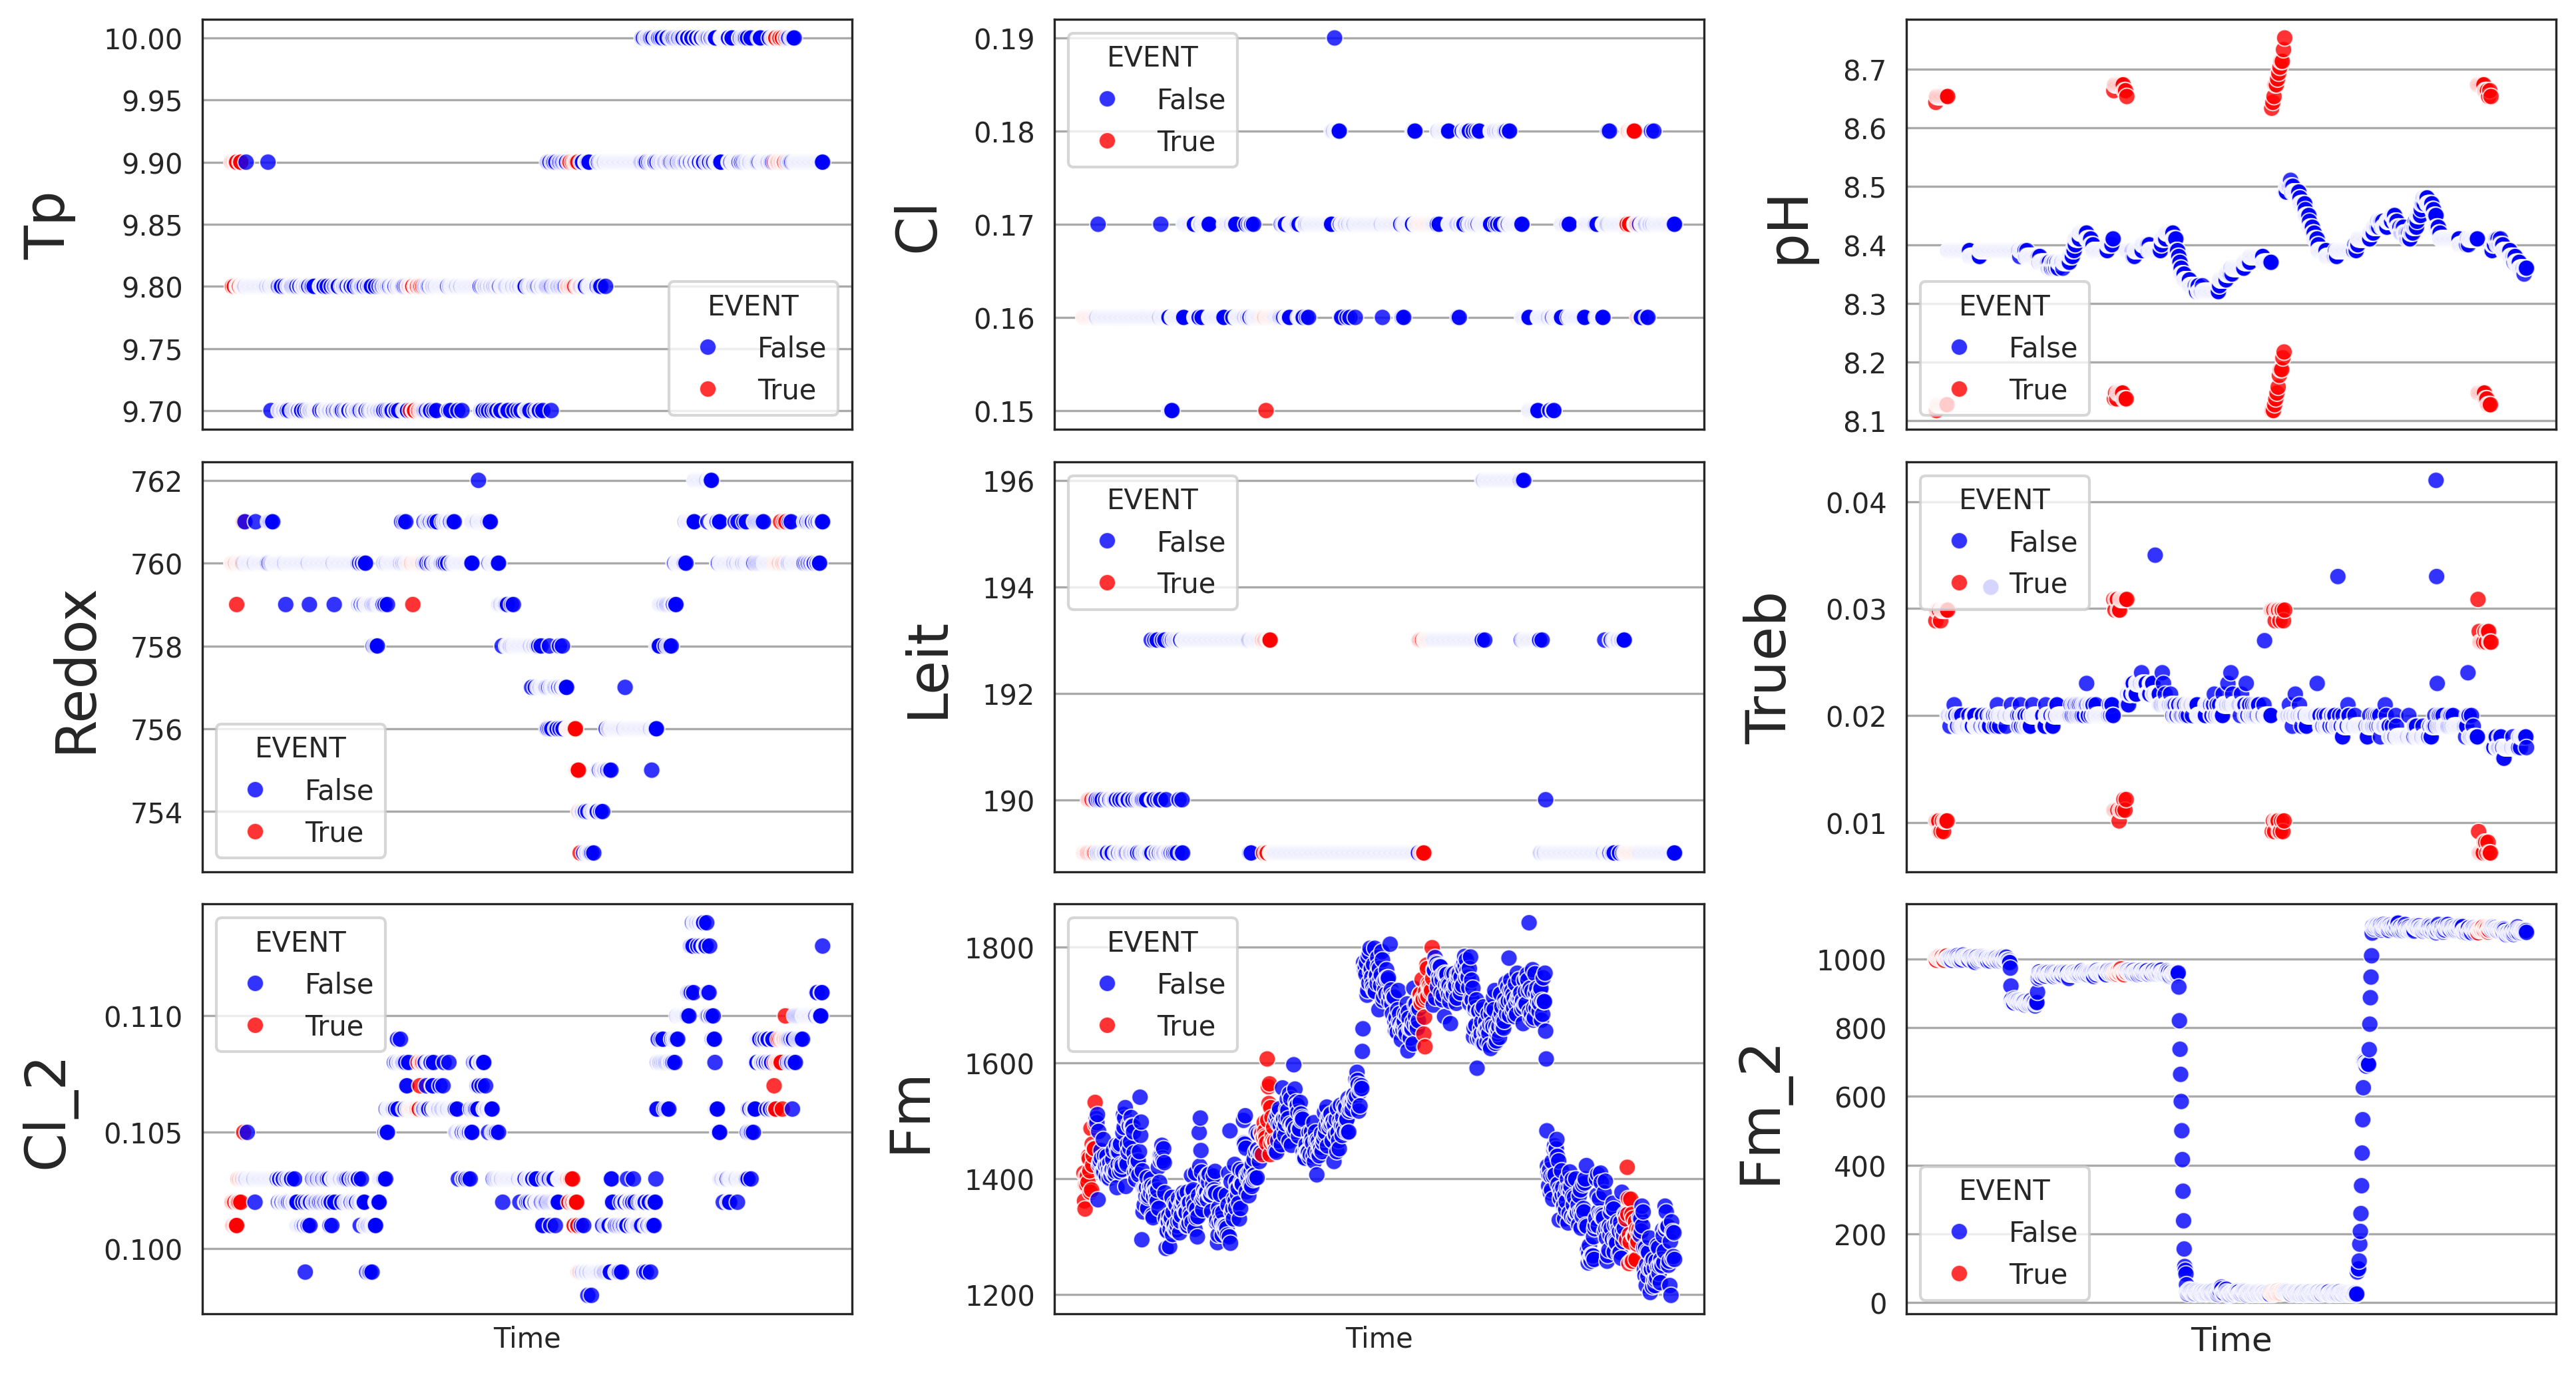

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Create a mock dataframe based on your snippet
# Replace this with your actual DataFrame (e.g., df = pd.read_csv('your_file.csv'))
data = wq_org.testing_data[1000:2000]

df = pd.DataFrame(data)

# Ensure the Time column is treated as datetime and 'EVENT' as string/boolean for legend mapping
df["Time"] = pd.to_datetime(df["Time"])

# 2. Setup the plot parameters
features = ["Tp", "Cl", "pH", "Redox", "Leit", "Trueb", "Cl_2", "Fm", "Fm_2"]
palette_colors = {False: "blue", True: "red"}

# Set a clean, white background style
sns.set_style("white")

# Create a 3x3 grid of subplots with increased DPI
fig, axes = plt.subplots(3, 3, figsize=(13, 7), sharex=True, dpi=300)
axes = axes.flatten()  # Flatten the 3x3 array into a 1D list of 9 axes

# 3. Loop through features and plot
for i, feature in enumerate(features):
    ax = axes[i]

    # Draw the scatterplot
    sns.scatterplot(
        data=df,
        x="Time",
        y=feature,
        hue="EVENT",
        palette=palette_colors,
        ax=ax,
        edgecolor="w",  # Replicates the white border on the dots
        alpha=0.8,
    )

    # Style the axes to match your image
    ax.set_ylabel(feature, fontsize=20, labelpad=10)
    ax.yaxis.grid(True, color="darkgrey", linewidth=0.8)  # Horizontal grids only
    ax.xaxis.grid(False)

    # Add the "Time" label ONLY to the bottom row of plots
    if i > 7:
        ax.set_xlabel("Time", fontsize=12)
        # Hide X-ticks entirely for the bottom row
        ax.set_xticks([])

# Adjust spacing so labels don't overlap
plt.tight_layout()
plt.show()

In [ ]:
encoder = enc_dense()
decoder = dec_dense()
model = auto_dense(encoder, decoder)
print(model)

EncoderDecoder(
  (encoder): Encoder(
    (fc0): Sequential(
      (0): Linear(in_features=9, out_features=180, bias=True)
      (1): Linear(in_features=180, out_features=180, bias=True)
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=180, out_features=180, bias=True)
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=180, out_features=180, bias=True)
    )
    (fc): Linear(in_features=180, out_features=90, bias=True)
  )
  (decoder): Decoder(
    (fc0): Sequential(
      (0): Linear(in_features=90, out_features=180, bias=True)
      (1): Dropout(p=0.2, inplace=False)
      (2): Linear(in_features=180, out_features=180, bias=True)
      (3): Linear(in_features=180, out_features=180, bias=True)
      (4): Linear(in_features=180, out_features=180, bias=True)
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=180, out_features=180, bias=True)
    )
    (fc_2): Linear(in_features=180, out_features=9, bias=True)
  )
)


In [ ]:
criterion = nn.MSELoss()  # Change based on your task
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

In [ ]:
prob_train = Trainer(
    model = model,
    train_dataset = X_train_dataset,
    val_dataset = X_val_dataset,
    batch_size = 32,
    criterion = criterion,
    optimizer = optimizer
)

cuda


In [ ]:
train_losses, val_losse = prob_train.train(num_epochs = 10)


Epoch 1/10


Validating: 100%|██████████| 873/873 [00:02<00:00, 420.48it/s, loss=0.0639]


Train Loss: 0.2997, Val Loss: 0.1728

Epoch 2/10


Validating: 100%|██████████| 873/873 [00:02<00:00, 406.59it/s, loss=0.0297]


Train Loss: 0.1394, Val Loss: 0.0705

Epoch 3/10


...

Train Loss: 0.0975, Val Loss: 0.0365

Epoch 9/10


Validating: 100%|██████████| 873/873 [00:02<00:00, 397.66it/s, loss=0.00742]


Train Loss: 0.0740, Val Loss: 0.0369

Epoch 10/10


Validating: 100%|██████████| 873/873 [00:02<00:00, 393.73it/s, loss=0.0301]

Train Loss: 0.0834, Val Loss: 0.0836


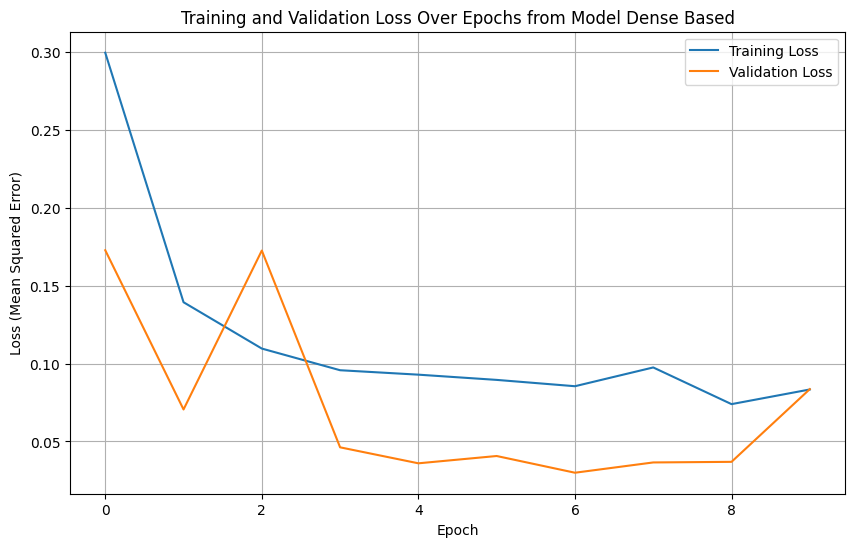

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losse, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs from Model Dense Based')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tqdm import tqdm
from torch.utils.data import DataLoader

device = ('cuda' if torch.cuda.is_available() else 'cpu')
test_loader = DataLoader(X_test_dataset, batch_size=32, shuffle=False)

model.to(device)
model.eval()

test_loss = []
outputs = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='Testing')
    for data, target in pbar:
        data, target = data.to(device), target.to(device)

        # Forward pass
        output = model(data.float())
        loss = criterion(output, target)

        # Track loss
        test_loss.append(loss.item())
        outputs.append(output.to("cpu").numpy())

        pbar.set_postfix({'loss': loss.item()})

y_pred_flat = np.concatenate(outputs, axis=0)

Testing: 100%|██████████| 4362/4362 [00:11<00:00, 380.01it/s, loss=0.0185]


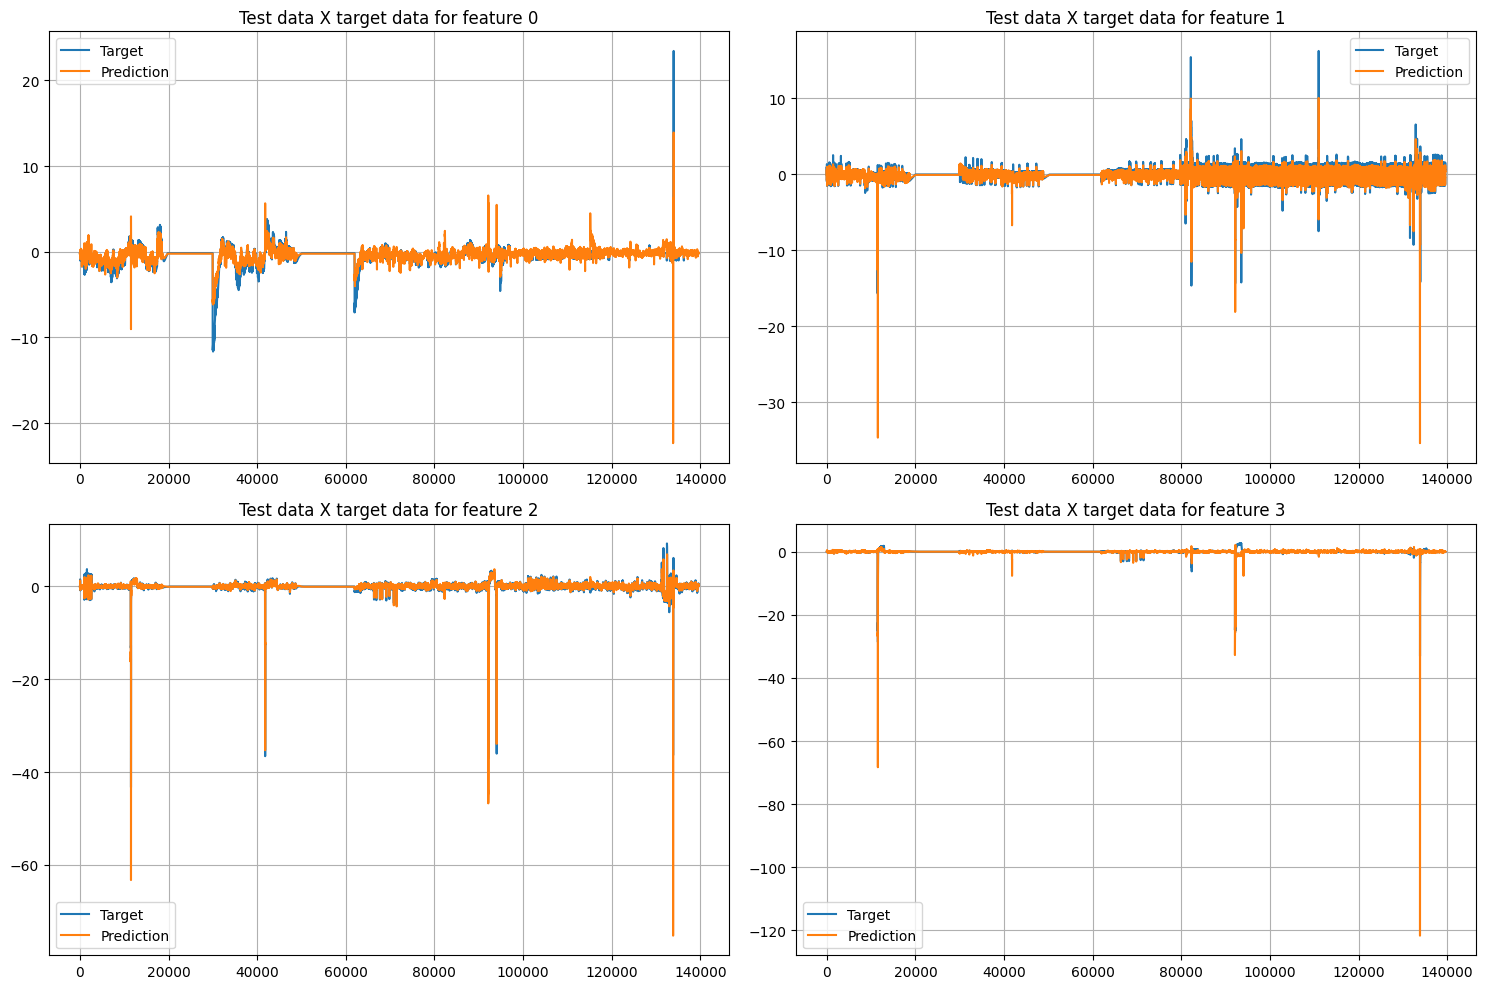

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Create a 2x2 grid for 4 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot up to 4 features, or fewer if there aren't that many
num_features_to_plot = min(4, y_pred_flat.shape[1])

for i in range(num_features_to_plot):
  axes[i].plot(wq_org.x_test.to_numpy()[:,i], label="Target")
  axes[i].plot(y_pred_flat[:,i], label="Prediction")
  axes[i].set_title(f'Test data X target for feature {i}')
  axes[i].legend()
  axes[i].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [ ]:
losses_from_test_ = []
for i in range(y_pred_flat.shape[0]):
  losses_from_test_.append(criterion(torch.from_numpy(y_pred_flat[i]).float(), torch.from_numpy(wq_org.x_test.to_numpy()[i]).float()))
losses_from_test = [float(i) for i in losses_from_test_]

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
val_loader = DataLoader(X_val_dataset, batch_size=32, shuffle=False)

model.to(device)
model.eval()

val_individual_loss = []
outputs = []

with torch.no_grad():
    pbar = tqdm(val_loader, desc='Testing')
    for data, target in pbar:
        data, target = data.to(device), target.to(device)

        # Forward pass
        output = model(data.float())
        loss = criterion(output, target)

        # Track loss
        val_individual_loss.append(loss.item())
        outputs.append(output.to("cpu").numpy())

        pbar.set_postfix({'loss': loss.item()})

y_pred_val_flat = np.concatenate(outputs, axis=0)

Testing: 100%|██████████| 873/873 [00:02<00:00, 386.18it/s, loss=0.0301]


In [ ]:
losses_from_val_ = []
for i in range(y_pred_val_flat.shape[0]):
  losses_from_val_.append(criterion(torch.from_numpy(y_pred_val_flat[i]).float(), torch.from_numpy(wq_org.x_val.to_numpy()[i]).float()))
losses_from_val = [float(i) for i in losses_from_val_]

In [ ]:
np.mean(losses_from_val)

np.float64(0.08361912922399424)

In [ ]:
best_trashhold = []
_ = []
best_f1_score = 0
for i in tqdm(range(len(losses_from_val_[:1000]))):
  trashhold = losses_from_val_[i]
  # Correct way to create anomaly_val_pred using a list comprehension
  anomaly_val_pred = [1 if loss > trashhold else 0 for loss in losses_from_val]
  class_report = classification_report(wq_org.y_val, anomaly_val_pred,output_dict=True)
  # Ensure 'True' key exists before accessing it
  if class_report["True"]["precision"] > best_f1_score:
    best_trashhold.append(trashhold)
    best_f1_score = class_report["True"]["precision"]
    _.append(best_f1_score)


100%|██████████| 1000/1000 [03:59<00:00,  4.18it/s]


In [ ]:
_

[0.017726852327612785,
 0.030612244897959183,
 0.353099730458221,
 0.4798387096774194,
 0.8305084745762712,
 0.8380952380952381]

In [ ]:
best_trashhold

[tensor(0.0130),
 tensor(0.0309),
 tensor(0.1932),
 tensor(0.2352),
 tensor(0.7628),
 tensor(0.8580)]

In [ ]:
anomaly_pred = []
for i in tqdm(losses_from_test):
  if i > best_trashhold[len(best_trashhold)-1]:
    anomaly_pred.append(1)
  else:
    anomaly_pred.append(0)

100%|██████████| 139566/139566 [00:00<00:00, 144629.64it/s]


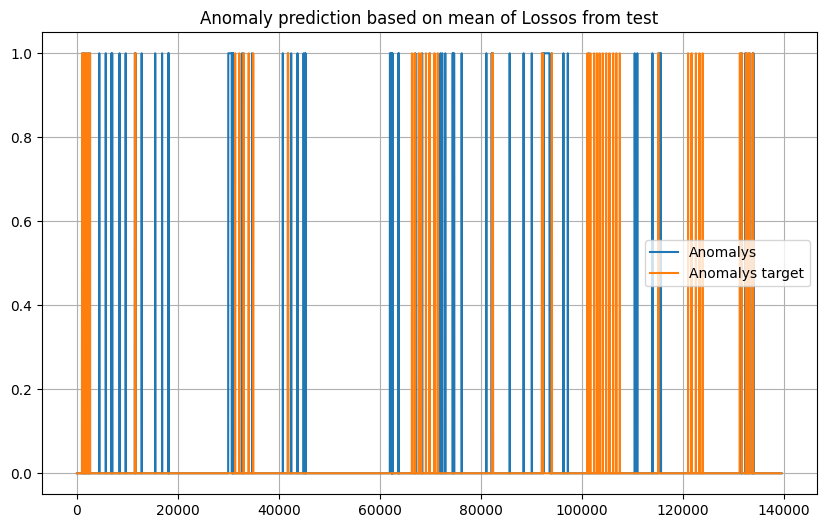

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(anomaly_pred, label='Anomalys')
plt.plot(wq_org.y_test, label='Anomalys target')
plt.title('Anomaly prediction based on mean of Lossos from test')
plt.legend()
plt.grid(True)
plt.show()

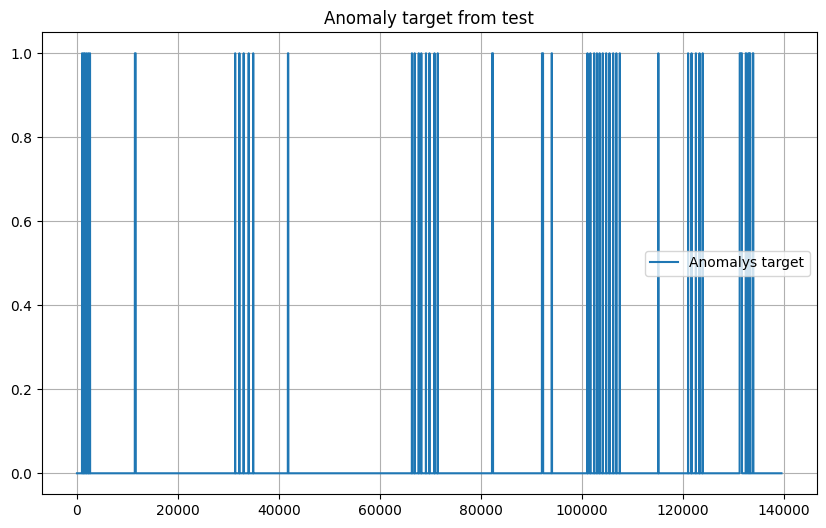

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(wq_org.y_test, label='Anomalys target')
plt.title('Anomaly target from test')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
conf_matrix = confusion_matrix(wq_org.y_test, anomaly_pred)
print("Confusion Matrix:")
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
print(conf_matrix_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0       134084         3153
Actual 1         1569          760


In [ ]:
class_report = classification_report(wq_org.y_test, anomaly_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98    137237
        True       0.19      0.33      0.24      2329

    accuracy                           0.97    139566
   macro avg       0.59      0.65      0.61    139566
weighted avg       0.98      0.97      0.97    139566



In [ ]:
best_trashhold = []
_ = []
best_f1_score = 0
for i in tqdm(range(len(losses_from_val_[:1000]))):
  trashhold = losses_from_val_[i]
  # Correct way to create anomaly_val_pred using a list comprehension
  anomaly_val_pred = [1 if loss > trashhold else 0 for loss in losses_from_val]
  class_report = classification_report(wq_org.y_val, anomaly_val_pred,output_dict=True)
  # Ensure 'True' key exists before accessing it
  if class_report["True"]["f1-score"] > best_f1_score:
    best_trashhold.append(trashhold)
    best_f1_score = class_report["True"]["f1-score"]
    _.append(best_f1_score)


100%|██████████| 1000/1000 [03:45<00:00,  4.43it/s]


In [ ]:
anomaly_pred = []
for i in tqdm(losses_from_test):
  if i > best_trashhold[len(best_trashhold)-1]:
    anomaly_pred.append(1)
  else:
    anomaly_pred.append(0)

100%|██████████| 139566/139566 [00:01<00:00, 88281.57it/s]


In [ ]:
class_report = classification_report(wq_org.y_test, anomaly_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    137237
        True       0.18      0.46      0.26      2329

    accuracy                           0.96    139566
   macro avg       0.59      0.71      0.62    139566
weighted avg       0.98      0.96      0.97    139566



In [ ]:
best_trashhold = []
_ = []
best_f1_score = 0
for i in tqdm(range(len(losses_from_val_[:1000]))):
  trashhold = losses_from_val_[i]
  # Correct way to create anomaly_val_pred using a list comprehension
  anomaly_val_pred = [1 if loss > trashhold else 0 for loss in losses_from_val]
  class_report = classification_report(wq_org.y_val, anomaly_val_pred,output_dict=True)
  # Ensure 'True' key exists before accessing it
  if class_report["accuracy"] > best_f1_score:
    best_trashhold.append(trashhold)
    best_f1_score = class_report["accuracy"]
    _.append(best_f1_score)

anomaly_pred = []
for i in tqdm(losses_from_test):
  if i > best_trashhold[len(best_trashhold)-1]:
    anomaly_pred.append(1)
  else:
    anomaly_pred.append(0)

class_report = classification_report(wq_org.y_test, anomaly_pred)
print("Classification Report: accuracy")
print(class_report)


100%|██████████| 139566/139566 [00:00<00:00, 165137.83it/s]


Classification Report: accuracy
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    137237
        True       0.19      0.44      0.26      2329

    accuracy                           0.96    139566
   macro avg       0.59      0.70      0.62    139566
weighted avg       0.98      0.96      0.97    139566



In [ ]:
conf_matrix = confusion_matrix(wq_org.y_test, anomaly_pred)
print("Confusion Matrix:")
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
print(conf_matrix_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0       132801         4436
Actual 1         1315         1014


In [ ]:
'''
o mais efetivo pra treinar nao seria tirar os casos onde e anomalia?
pra que o treino aprenda a reconstruir so oque nao e anomalia e dai no teste que venha
os valores com anomalia?
'''